## Stiff ODEs and Implicit Methods
Mechanical System with High Damping

### 1. Introduction & System Selection

This project will examine and compare explicit Forward Euler and implicit Backward Euler methods for solving an overdamped spring-mass system with the first-order differential equation

$$\frac{dx}{dt} = -\frac{k}{c}x + \frac{1}{c}F(t)$$

where $\frac{k}{c} = 5000 s^{-1}$, $F(t) = 10\sin{(t)}$, and the initial condition $x(0) = 1 m$. This gives us the equation in standard form:

$$\frac{dx}{dt} = -5000x + 0.002\sin{(t)}$$

Overdamped spring-mass systems are important in practice because it allows systems to return to equilibrium and prevent wild oscillations.

### 2. Demonstration of Stiffness

In [51]:
import numpy as np
import matplotlib.pyplot as plt

lam = 5000
# Define OD dx/dt = f(t,y)
def f(t, y):
    return -lam*y + 0.002*np.sin(t)

# Define exact solution
    '''
    Solution y(t) = e^(-lambda*t)y0 + integral[e^(-lambda*(t-s)) * g(s)]ds
    lambda = 5000
    g(t) = 0.002sin(t)
    y(0) = 1
    '''
def y_exact(t):
    return np.exp(-5000*t) + 0.002/(5000**2 + 1) * (5000*np.sin(t) - np.cos(t) + np.exp(-5000*t)) # citation: (1)
    
# Initial condition
y0 = 1
t0 = 0
tf = 0.2

Attempting Euler's Forward with h = 0.1...


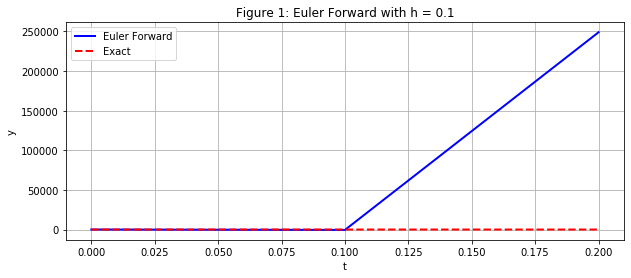

Maximum value reached: 2.49e+05
Result: Euler's Forward method diverges with step size h = 0.1

Trying with h = 0.0001...


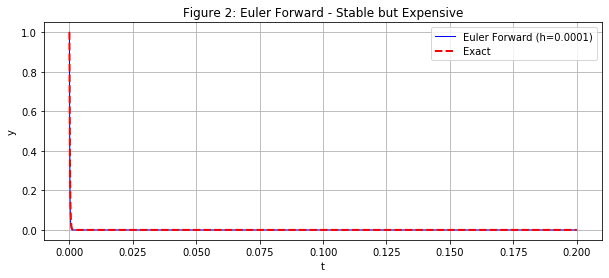

Number of steps needed: 2001
Maximum error: 1.18e-01
Result: With a much smaller step size h = 0.0001, the solution is stable.


In [52]:
def euler_forward(f, y0, t0, tf, h):
    """
    Euler's Forward method (explicit)

    y_{n+1} = y_n + h * f(t_n, y_n)

    Returns: arrays of time and solution
    """
    # Setup
    num_steps = int((tf - t0) / h)
    t = np.zeros(num_steps + 1)
    y = np.zeros(num_steps + 1)

    t[0] = t0
    y[0] = y0

    # Time stepping
    for n in range(num_steps):
        y[n+1] = y[n] + h * f(t[n], y[n])
        t[n+1] = t[n] + h
    return t, y


# Try Euler's Forward with h = 0.1
h_forward = 0.1
print(f"Attempting Euler's Forward with h = {h_forward}...")

try:
    t_forward, y_forward = euler_forward(f, y0, t0, tf, h_forward)

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(t_forward, y_forward, 'b-', label='Euler Forward', linewidth=2)
    plt.plot(t_forward, y_exact(t_forward), 'r--', label='Exact', linewidth=2)
    plt.xlabel('t')
    plt.ylabel('y')
    plt.title(f'Figure 1: Euler Forward with h = {h_forward}')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Maximum value reached: {np.max(np.abs(y_forward)):.2e}")
except:
    print("Solution blew up!")
    
print("Result: Euler's Forward method diverges with step size h = 0.1")
    
    
# Try with MUCH smaller step size
h_forward_stable = 0.0001

print(f"\nTrying with h = {h_forward_stable}...")
t_forward, y_forward = euler_forward(f, y0, t0, tf, h_forward_stable)

plt.figure(figsize=(10, 4))
plt.plot(t_forward, y_forward, 'b-', label=f'Euler Forward (h={h_forward_stable})', linewidth=1)
plt.plot(t_forward, y_exact(t_forward), 'r--', label='Exact', linewidth=2)
plt.xlabel('t')
plt.ylabel('y')
plt.title('Figure 2: Euler Forward - Stable but Expensive')
plt.legend()
plt.grid(True)
plt.show()

print(f"Number of steps needed: {len(t_forward)}")
print(f"Maximum error: {np.max(np.abs(y_forward - y_exact(t_forward))):.2e}")
print("Result: With a much smaller step size h = 0.0001, the solution is stable.")

The overdamped spring-mass system is linear, so I can calculate the stiffness ratio as the ratio of the largest to smallest eigenvalue magnitude. For the equation

$$\frac{dx}{dt} = -5000x + 0.002\sin{(t)}$$

the matrix $A = -5000$, and solving for its eigenvalue gives $\lambda = -5000$. I relate $\sin{(t)}$ to a matrix that has eigenvalues of $\pm i$ and find its magnitude is $1$.$^{(2)}$ Therefore, the stiffness ratio is calculated as

$$\frac{|-5000|}{|1|} = 5000$$

This system is stiff because of the constant $\frac{k}{c} = 5000$ being very large meaning the solution decays very fast. In order to see this trend with Euler's Forward method, small steps are required to solve. Therefore, it is more practical to use implicit methods, rather than explicit methods like Euler's Foward, because they do not require small step sizes to converge.

In [4]:
'''
    Euler's Forward stability condition: h < 2/lamda
    lambda = 5000
'''
max_h = 2/5000
print("The maximum step size for Euler's Forward stability is", max_h)

# number of steps = tf - t0 / h
print((tf-t0)/max_h, "steps are needed for the full simulation of", tf-t0, "seconds.")

print("Computational burden: O(n)")

The maximum step size for Euler's Forward stability is 0.0004
500.0 steps are needed for the full simulation of 0.2 seconds.
Computational burden: O(n)


### 3. Mathematical Setup

In [11]:
# Functions for Newton-Raphson Implementation

def residual(y_next, y_n, t_next, h):
    """
    Residual function for implicit Euler.

    We want to solve: y_{n+1} = y_n + h * f(t_{n+1}, y_{n+1})

    Rearrange: g(y_{n+1}) = y_{n+1} - y_n - h*f(t_{n+1}, y_{n+1}) = 0

    Parameters:
    - y_next: the unknown y_{n+1} we're solving for
    - y_n: the known value at previous time step
    - t_next: time t_{n+1}
    - h: step size

    Returns: residual g(y_{n+1})
    """
    return y_next - y_n - h * f(t_next, y_next)

def residual_derivative(h):
    """
    Derivative of residual with respect to y_{n+1}.

    For our problem: f(t,y) = -lambda*y + g(t)
    So: df/dy = -lambda = -5000

    Therefore: g'(y_{n+1}) = 1 - h*(df/dy) = 1 - h*(-lambda) = 1 + lambda*h

    This is CONSTANT for our linear problem!

    Parameters:
    - h: step size

    Returns: g'(y_{n+1})
    """
    df_dy = -lam  # For our specific problem
    return 1 - h * df_dy

def newton_raphson_step(y_n, t_next, h, tol=1e-6, max_iter=20, verbose=False):
    """
    Solve for y_{n+1} using Newton-Raphson iteration.

    We want to find y_{n+1} such that g(y_{n+1}) = 0

    Newton-Raphson: y^(k+1) = y^(k) - g(y^(k)) / g'(y^(k))

    Parameters:
    - y_n: solution at previous time step
    - t_next: time t_{n+1}
    - h: step size
    - tol: convergence tolerance
    - max_iter: maximum iterations
    - verbose: print iteration details

    Returns: (y_{n+1}, number of iterations)
    """
    # Initial guess: use explicit Euler as predictor
    y_guess = y_n

    # Compute g' once (constant for our linear problem)
    g_prime = residual_derivative(h)

    if verbose:
        print(f"\n  Starting Newton-Raphson at t = {t_next:.4f}")
        print(f"  Initial guess: y = {y_guess:.6f}")
        print(f"  g'(constant) = {g_prime:.6f}\n")

    function_evals = 0    
        
    # Newton-Raphson iteration
    for k in range(max_iter):
        # Evaluate residual
        g = residual(y_guess, y_n, t_next, h)
        function_evals += 1
        

        if verbose:
            print(f"  Iteration {k}: y = {y_guess:.6f}, g = {g:.2e}")

        # Check convergence
        if abs(g) < tol:
            if verbose:
                print(f"  ✓ Converged in {k} iterations!\n")
            return y_guess, k, function_evals

        # Newton-Raphson update
        delta = -g / g_prime
        y_guess = y_guess + delta

    # Did not converge
    print(f"  ✗ Warning: Newton-Raphson did not converge after {max_iter} iterations")
    return y_guess, max_iter, function_evals

def euler_backward(f, y0, t0, tf, h, tol=1e-6, verbose_freq=0):
    """
    Euler's Backward (Implicit Euler) method with Newton-Raphson.

    For each time step:
    1. Solve y_{n+1} = y_n + h*f(t_{n+1}, y_{n+1}) using Newton-Raphson
    2. Move to next time step

    Parameters:
    - f: ODE function dy/dt = f(t, y)
    - y0: initial condition
    - t0, tf: time span
    - h: step size
    - tol: Newton-Raphson tolerance
    - verbose_freq: print details every N steps (0 = no printing)

    Returns:
    - t: array of time points
    - y: array of solution values
    - iterations: array of NR iterations per step
    """
    # Setup
    num_steps = int((tf - t0) / h)
    t = np.zeros(num_steps + 1)
    y = np.zeros(num_steps + 1)
    iterations = np.zeros(num_steps, dtype=int)

    # Initial condition
    t[0] = t0
    y[0] = y0
    total_func_evals = 0

    print(f"\nStarting Euler's Backward method:")
    print(f"  Time span: [{t0}, {tf}]")
    print(f"  Step size: h = {h}")
    print(f"  Number of steps: {num_steps}")
    print(f"  NR tolerance: {tol}\n")

    # Time stepping loop
    for n in range(num_steps):
        # Solve for y_{n+1} using Newton-Raphson
        verbose = (verbose_freq > 0 and (n % verbose_freq == 0))

        y[n+1], iterations[n], func_evals = newton_raphson_step(y[n], t[n] + h, h, tol=tol, verbose=verbose)
        
        t[n+1] = t[n] + h
        total_func_evals += func_evals

    print(f"✓ Completed!")
    print(f"  Average NR iterations per step: {np.mean(iterations):.2f}")
    print(f"  Max NR iterations: {np.max(iterations)}")
    print(f"  Min NR iterations: {np.min(iterations)}")
    print(f"  Total function evaluations: {total_func_evals}\n")
    
    return t, y, iterations

### 4. Implementation


Starting Euler's Backward method:
  Time span: [0.0, 0.2]
  Step size: h = 0.0001
  Number of steps: 2000
  NR tolerance: 1e-06

✓ Completed!
  Average NR iterations per step: 0.02
  Max NR iterations: 1
  Min NR iterations: 0
  Total function evaluations: 2033


Starting Euler's Backward method:
  Time span: [0.0, 0.2]
  Step size: h = 0.0004
  Number of steps: 500
  NR tolerance: 1e-06

✓ Completed!
  Average NR iterations per step: 0.03
  Max NR iterations: 1
  Min NR iterations: 0
  Total function evaluations: 514


Starting Euler's Backward method:
  Time span: [0.0, 0.2]
  Step size: h = 0.001
  Number of steps: 200
  NR tolerance: 1e-06

✓ Completed!
  Average NR iterations per step: 0.04
  Max NR iterations: 1
  Min NR iterations: 0
  Total function evaluations: 209


Starting Euler's Backward method:
  Time span: [0.0, 0.2]
  Step size: h = 0.01
  Number of steps: 20
  NR tolerance: 1e-06

✓ Completed!
  Average NR iterations per step: 0.35
  Max NR iterations: 1
  Min NR ite

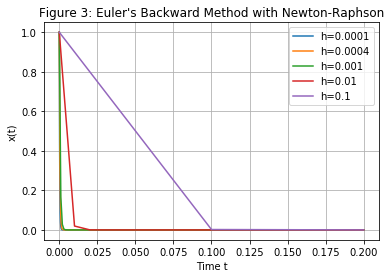

In [56]:
h = ([0.0001, max_h, 0.001, 0.01, 0.1])
y0 = 1.0
t0 = 0.0
tf = 0.2

for i in range(len(h)):
    t, y, iterations = euler_backward(f, y0, t0, tf, h[i], tol=1e-6, verbose_freq=0)
    plt.plot(t, y, label=f'h={h[i]}')
    
plt.xlabel('Time t')
plt.ylabel('x(t)')
plt.title("Figure 3: Euler's Backward Method with Newton-Raphson")
plt.legend()
plt.grid(True)
plt.show()

Notice that for all the step sizes, even as h increases, the solutions still converge for Euler's Backward.

### 5. Results & Analysis
*Table 1:* **Step Size Comparison**

|Method|range of stable h|
|:--:|:--:|
|Euler's Foward|0 < h $\leq$ 0.0004|
|Euler's Backward|h > 0|

As solved by the stability conditions of Euler's Forward, the maximum stable step size for this method is 0.0004, while Euler's backward can manage step sizes for any h > 0.

#### Accuracy vs. Computational Cost

In [14]:
def euler_forward(f, y0, t0, tf, h):
    """
    Euler's Forward method (explicit)

    y_{n+1} = y_n + h * f(t_n, y_n)

    Returns: arrays of time and solution
    """
    # Setup
    num_steps = int((tf - t0) / h)
    t = np.zeros(num_steps + 1)
    y = np.zeros(num_steps + 1)
    iterations = np.zeros(num_steps, dtype=int)

    t[0] = t0
    y[0] = y0
    total_evals = 0
    iterations = 1 # constant

    print(f"\nStarting Euler's Forward method:")
    print(f"  Time span: [{t0}, {tf}]")
    print(f"  Step size: h = {h}")
    print(f"  Number of steps: {num_steps}\n")
    
    # Time stepping
    for n in range(num_steps):
        y[n+1] = y[n] + h * f(t[n], y[n])
        t[n+1] = t[n] + h
        total_evals += 1
        
    print(f"✓ Completed!")
    print(f"  Average FE iterations per step: {np.mean(iterations):.2f}")
    print(f"  Max FE iterations: {np.max(iterations)}")
    print(f"  Min FE iterations: {np.min(iterations)}")
    print(f"  Total function evaluations: {total_evals}\n")

    return t, y

In [15]:
h = np.array([0.0001, 0.0004, 0.001, 0.01, 0.1])

for i in range(len(h)):
    t, y = euler_forward(f, 1, 0, 0.2, h[i])


Starting Euler's Forward method:
  Time span: [0, 0.2]
  Step size: h = 0.0001
  Number of steps: 2000

✓ Completed!
  Average FE iterations per step: 1.00
  Max FE iterations: 1
  Min FE iterations: 1
  Total function evaluations: 2000


Starting Euler's Forward method:
  Time span: [0, 0.2]
  Step size: h = 0.0004
  Number of steps: 500

✓ Completed!
  Average FE iterations per step: 1.00
  Max FE iterations: 1
  Min FE iterations: 1
  Total function evaluations: 500


Starting Euler's Forward method:
  Time span: [0, 0.2]
  Step size: h = 0.001
  Number of steps: 200

✓ Completed!
  Average FE iterations per step: 1.00
  Max FE iterations: 1
  Min FE iterations: 1
  Total function evaluations: 200


Starting Euler's Forward method:
  Time span: [0, 0.2]
  Step size: h = 0.01
  Number of steps: 20

✓ Completed!
  Average FE iterations per step: 1.00
  Max FE iterations: 1
  Min FE iterations: 1
  Total function evaluations: 20


Starting Euler's Forward method:
  Time span: [0, 0.2]

*Table 2:* **Euler's Backward**

|Step size|Number of time steps|Iterations per step|Total function evaluations|
|:--:|:--:|:--:|:--:|
|0.0001|2000|0.02|2033|
|0.0004|500|0.03|514|
|0.001|200|0.04|209|
|0.01|20|0.35|27|
|0.1|2|1.00|4|

*Table 3:* **Euler's Forward**

|Step size|Number of time steps|Iterations per step|Total function evaluations|
|:--:|:--:|:--:|:--:|
|0.0001|2000|1.00|2000|
|0.0004|500|1.00|500|
|0.001|200|1.00|200|
|0.01|20|1.00|20|
|0.1|2|1.00|2|

While Euler's Backward has more function evaluations for each step size compared to Euler's Forward, the iterations per step starts off very small before gradually increasing to be comparable to the average iterations per step for Euler's Forward. So Euler's Backward method is more expensive per step, but it is still more computaitonal efficient.

#### Convergence Behavior


Starting Euler's Backward method:
  Time span: [0.0, 0.2]
  Step size: h = 0.0001
  Number of steps: 2000
  NR tolerance: 1e-06

✓ Completed!
  Average NR iterations per step: 0.02
  Max NR iterations: 1
  Min NR iterations: 0
  Total function evaluations: 2033


Starting Euler's Backward method:
  Time span: [0.0, 0.2]
  Step size: h = 0.0004
  Number of steps: 500
  NR tolerance: 1e-06

✓ Completed!
  Average NR iterations per step: 0.03
  Max NR iterations: 1
  Min NR iterations: 0
  Total function evaluations: 514


Starting Euler's Backward method:
  Time span: [0.0, 0.2]
  Step size: h = 0.001
  Number of steps: 200
  NR tolerance: 1e-06

✓ Completed!
  Average NR iterations per step: 0.04
  Max NR iterations: 1
  Min NR iterations: 0
  Total function evaluations: 209


Starting Euler's Backward method:
  Time span: [0.0, 0.2]
  Step size: h = 0.01
  Number of steps: 20
  NR tolerance: 1e-06

✓ Completed!
  Average NR iterations per step: 0.35
  Max NR iterations: 1
  Min NR ite

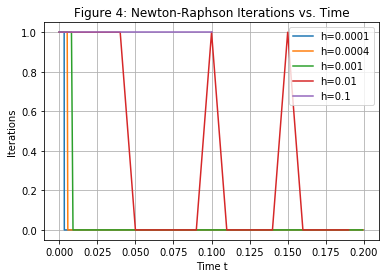

In [54]:
h = np.array([0.0001, max_h, 0.001, 0.01, 0.1])
y0 = 1.0
t0 = 0.0
tf = 0.2

for i in range(len(h)):
    t, y, iterations = euler_backward(f, y0, t0, tf, h[i], tol=1e-6, verbose_freq=0)
    plt.plot(t[:-1], iterations, label=f'h={h[i]}')
    
plt.xlabel("Time t")
plt.ylabel("Iterations")
plt.title("Figure 4: Newton-Raphson Iterations vs. Time")
plt.legend()
plt.grid(True)
plt.show()

As step size increases, Euler's Backward requires more iterations for a greater length of time to converge. We can see that smaller step sizes decrease in iterations sooner than the next largest step size, and the largest h = 0.1 is not shown to decrease in the graph's range.

In general, a higher quality initial guess will take less iterations to converge because the initial solution will already be closer to the exact solution than a poor guess.

Nonlinear systems require more iterations to solve because as the number of curves increase, it becomes harder to approximate them linearly.

#### Solution Quality


Starting Euler's Backward method:
  Time span: [0.0, 0.1]
  Step size: h = 0.0001
  Number of steps: 1000
  NR tolerance: 1e-06

✓ Completed!
  Average NR iterations per step: 0.03
  Max NR iterations: 1
  Min NR iterations: 0
  Total function evaluations: 1033


Starting Euler's Backward method:
  Time span: [0.0, 0.1]
  Step size: h = 0.0004
  Number of steps: 250
  NR tolerance: 1e-06

✓ Completed!
  Average NR iterations per step: 0.06
  Max NR iterations: 1
  Min NR iterations: 0
  Total function evaluations: 264


Starting Euler's Backward method:
  Time span: [0.0, 0.1]
  Step size: h = 0.001
  Number of steps: 100
  NR tolerance: 1e-06

✓ Completed!
  Average NR iterations per step: 0.09
  Max NR iterations: 1
  Min NR iterations: 0
  Total function evaluations: 109


Starting Euler's Backward method:
  Time span: [0.0, 0.1]
  Step size: h = 0.01
  Number of steps: 10
  NR tolerance: 1e-06

✓ Completed!
  Average NR iterations per step: 0.50
  Max NR iterations: 1
  Min NR ite

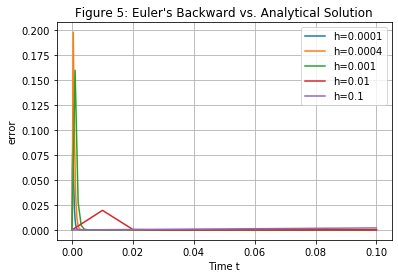

In [55]:
tf = 0.1

for i in range(len(h)):
    t, y, iterations = euler_backward(f, y0, t0, tf, h[i], tol=1e-6, verbose_freq=0)
    error = np.abs(y_exact(t) - y)
    plt.plot(t, error, label=f'h={h[i]}')
    
# Plot the results
plt.xlabel('Time t')
plt.ylabel('error')
plt.title('Figure 5: Euler\'s Backward vs. Analytical Solution')
plt.legend()
plt.grid(True)
plt.show()

The solution error peaks on *Figure 5* at the beginning of solving and almost immediately drops down to a near 0 error value. Even for larger step sizes, such as h = 0.1, the error plots remain near 0, confirming that Euler's Backward is stable and the solution is accurate even as step sizes increase.

### 7. Conclusion

Implicit methods, like Backward Euler with Newton Raphson, are generally more practical in solving equations because they do not have a step size limit for stability, while explicit methods, like Forward Euler, are only stable for very small step sizes. Implicit methods are best used for solving stiff equations while explicit methods are best for non-stiff equations that have more gradual changes. The biggest challenges I faced were trying to graph my results, such as for the convergence error where I had to test and adjust my arrays to make them plottable. I also had trouble adjusing the code for Euler's Forward method to keep track of the iterations, number of steps, and function evaluations for each run.

### References

1. ```y_exact```
   - I searched up and received a solution from Google Gemini for the integral in the analytical solution
$$y(t) = e^{-\lambda t}y_0 + \int_0^t e^{-\lambda (t-s)}g(s)ds$$


2. Finding magnitude of eigenvalues $\pm i$
   - I searched up "how do i relate sin(t) to an eigenvalue, stiffness ratio" in Google Gemini
   - Result: "sin(t) is the result of a system that has eigenvalues of $i$ and $-i$ ... In the context of your stiffness calculation, we use the magnitude (absolute value) of these eigenvalues"
   